## EDA - Первичный анализ данных
**Цель:** Анализ распределения классов, проверка качества изображений, выявление проблем   
**Данные:** data/train/, data/test/ - папки с эмоциями, изображения в оттенках серого

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from collections import Counter

from src.constants import DATA_PATH
from src.data.loader import create_dataloaders, EmotionImageDataset

In [2]:
transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(f"{DATA_PATH}/train", transform=transform)
test_dataset = datasets.ImageFolder(f"{DATA_PATH}/test", transform=transform)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train size: 28709
Test size: 7178


In [6]:
dataset = EmotionImageDataset(DATA_PATH, split="train", image_size=48)
dataset_test = EmotionImageDataset(DATA_PATH, split="test", image_size=48)

print("Размер датасета:", len(dataset) + len(dataset_test))
print("Размер train:", len(dataset))
print("Размер test:", len(dataset_test))

img, label = dataset[0]

print("Тип изображения:", type(img))
print("Shape:", img.shape)
print("Label:", label)

Размер датасета: 35887
Размер train: 28709
Размер test: 7178
Тип изображения: <class 'torch.Tensor'>
Shape: torch.Size([1, 48, 48])
Label: 0


In [4]:
bad = 0

for i in range(len(dataset)):
    img, _ = dataset[i]
    if img is None:
        bad += 1

print("Битые изображения:", bad)

KeyboardInterrupt: 

In [5]:
batch_size = 32
train_loader, val_loader, test_loader = create_dataloaders(DATA_PATH, batch_size=batch_size)
print("Train:", len(train_loader.dataset))
print("Val:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))

Train: 22967
Val: 5742
Test: 7178


In [ ]:
labels = [label for _, label in train_dataset]
counts = Counter(labels)

plt.bar(train_dataset.classes, counts.values())
plt.title("Class distribution")
plt.xticks(rotation=45)
plt.show()

KeyboardInterrupt: 

Вывод: классы несбалансированы, некоторые эмоции (например, disgust) встречаются редко, а некоторые очень часто

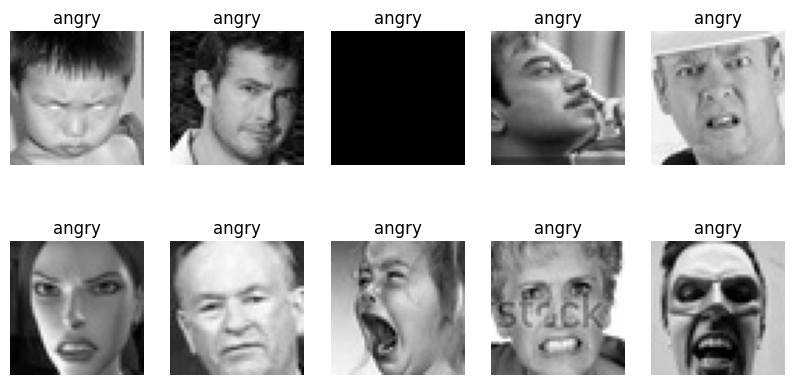

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.show()

Вывод: изображения маленькие (48×48) и присутствет шум. Где то есть надписи, что тоже может портить обучение

In [ ]:
means = []
stds = []

for img, _ in train_dataset:
    means.append(img.mean().item())
    stds.append(img.std().item())

print("Mean:", np.mean(means))
print("Std:", np.mean(stds))

Mean: 0.5077385789615779
Std: 0.21202472877158018
